In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# load the data
data = pd.read_csv('../data/output_fcd.csv', sep=';')

# print the head
print(data.head())

   timestep_time  vehicle_angle vehicle_id  vehicle_lane  vehicle_pos  \
0            0.0         229.42       veh0  24913519#0_2         5.10   
1            1.0         229.12       veh0  24913519#0_2         7.20   
2            2.0         228.82       veh0  24913519#0_2        10.91   
3            3.0         228.82       veh0  24913519#0_2        16.97   
4            4.0         228.82       veh0  24913519#0_2        25.29   

   vehicle_slope  vehicle_speed   vehicle_type  vehicle_x  vehicle_y  
0            0.0           0.00  veh_passenger    1041.41     377.58  
1            0.0           2.10  veh_passenger    1039.83     376.21  
2            0.0           3.71  veh_passenger    1037.04     373.76  
3            0.0           6.06  veh_passenger    1032.48     369.78  
4            0.0           8.32  veh_passenger    1026.22     364.30  


In [3]:
average_speed_per_timestep = data.groupby('timestep_time')['vehicle_speed'].mean().reset_index()
average_speed_per_timestep.columns = ['timestep_time', 'average_vehicle_speed']
average_speed_per_timestep = average_speed_per_timestep.sort_values('timestep_time')

In [4]:
# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(average_speed_per_timestep['average_vehicle_speed'].values.reshape(-1, 1))

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
X, y = create_sequences(data_normalized, seq_length)

In [5]:

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

# Predict using the model
predictions = model.predict(X_val)
predictions = scaler.inverse_transform(predictions)

# Evaluate the model
mse = model.evaluate(X_val, y_val)
print(f'Mean Squared Error: {mse}')

Epoch 1/20
180/180 [==============================] - 10s 32ms/step - loss: 0.0134 - val_loss: 0.0076
Epoch 2/20
180/180 [==============================] - 5s 25ms/step - loss: 0.0061 - val_loss: 0.0054
Epoch 3/20
180/180 [==============================] - 4s 24ms/step - loss: 0.0040 - val_loss: 0.0031
Epoch 4/20
180/180 [==============================] - 4s 24ms/step - loss: 0.0025 - val_loss: 0.0028
Epoch 5/20
180/180 [==============================] - 4s 25ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 6/20
180/180 [==============================] - 4s 24ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 7/20
180/180 [==============================] - 5s 29ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 8/20
180/180 [==============================] - 5s 27ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 9/20
180/180 [==============================] - 5s 26ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 10/20
180/180 [==============================] - 5s 27ms/step - loss: 0.0017 - val_l

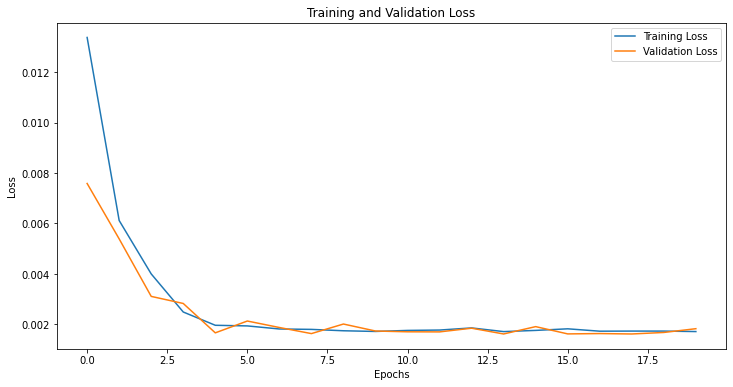

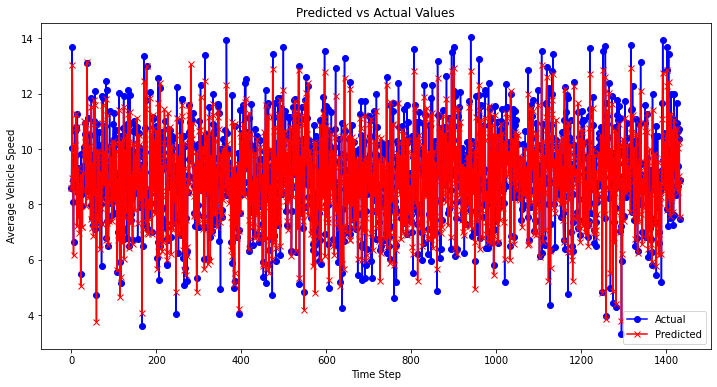

In [6]:

# Plot the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot the predicted vs actual values
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_val)), scaler.inverse_transform(y_val), marker='o', linestyle='-', color='b', label='Actual')
plt.plot(range(len(predictions)), predictions, marker='x', linestyle='-', color='r', label='Predicted')
plt.title('Predicted vs Actual Values')
plt.xlabel('Time Step')
plt.ylabel('Average Vehicle Speed')
plt.legend()
plt.show()


In [7]:
# Split the data into training and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Predict using the model
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print(f'Mean Squared Error: {mse}')


Epoch 1/20
180/180 [==============================] - 9s 33ms/step - loss: 0.0156 - val_loss: 0.0084
Epoch 2/20
180/180 [==============================] - 4s 25ms/step - loss: 0.0066 - val_loss: 0.0058
Epoch 3/20
180/180 [==============================] - 4s 24ms/step - loss: 0.0045 - val_loss: 0.0036
Epoch 4/20
180/180 [==============================] - 4s 24ms/step - loss: 0.0032 - val_loss: 0.0027
Epoch 5/20
180/180 [==============================] - 5s 26ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 6/20
180/180 [==============================] - 4s 24ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 7/20
180/180 [==============================] - 4s 24ms/step - loss: 0.0019 - val_loss: 0.0024
Epoch 8/20
180/180 [==============================] - 4s 24ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 9/20
180/180 [==============================] - 4s 24ms/step - loss: 0.0019 - val_loss: 0.0023
Epoch 10/20
180/180 [==============================] - 4s 24ms/step - loss: 0.0018 - val_lo

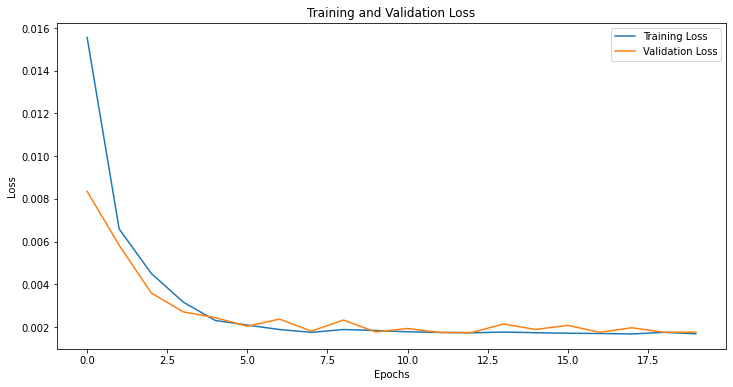

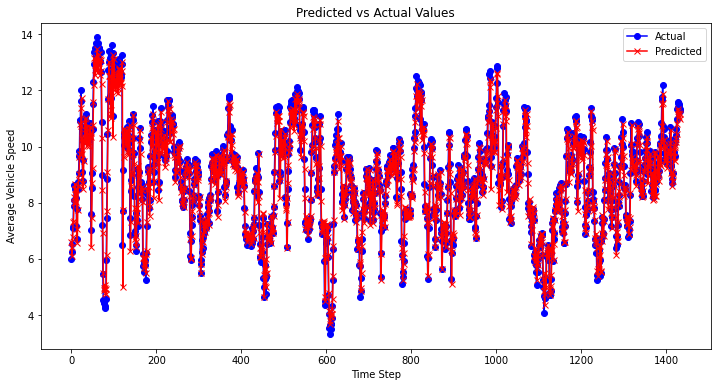

In [8]:

# Plot the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot the predicted vs actual values
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), scaler.inverse_transform(y_test.reshape(-1, 1)), marker='o', linestyle='-', color='b', label='Actual')
plt.plot(range(len(predictions)), predictions, marker='x', linestyle='-', color='r', label='Predicted')
plt.title('Predicted vs Actual Values')
plt.xlabel('Time Step')
plt.ylabel('Average Vehicle Speed')
plt.legend()
plt.show()
